Project 7: The Phantom Correlation — When a Descriptor Looks Important for the Wrong Reason 

Course:
Machine Learning and Data Analytics in Materials Science (MS5480)

Submitted by:
THANUMALAYAPERUMAL T
MS25MTECH14011
ms25mtech14011@iith.ac.in

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

1. Generate the dataset

In [25]:
rng = np.random.default_rng(789)

nA = 130
nB = 130
n = nA + nB

family = np.array(["family_A"] * nA + ["family_B"] * nB)

true_driver_A = rng.uniform(0, 10, nA)
true_driver_B = rng.uniform(0, 10, nB)
true_driver = np.concatenate([true_driver_A, true_driver_B])

# Shadow feature: strong proxy in A, weaker in B
shadow_A = 1.25 * true_driver_A + rng.normal(0, 0.7, nA)
shadow_B = 0.75 * true_driver_B + 1.2 * np.sin(true_driver_B / 2) + rng.normal(0, 1.2, nB)
shadow_feature = np.concatenate([shadow_A, shadow_B])

weak_feature = rng.uniform(-3, 3, n)
noise1 = rng.normal(0, 1, n)
noise2 = rng.normal(0, 1, n)

target = (
    2.3 * np.sin(true_driver / 2)
    + 0.55 * weak_feature
    + rng.normal(0, 0.45, n)
)

df = pd.DataFrame({
    "family_hidden": family,
    "true_driver": true_driver,
    "shadow_feature": shadow_feature,
    "weak_feature": weak_feature,
    "noise1": noise1,
    "noise2": noise2,
    "target": target
})

Any shadow-target correlation is inherited through true_driver. That is confounding by definition.

2. Scatter plots

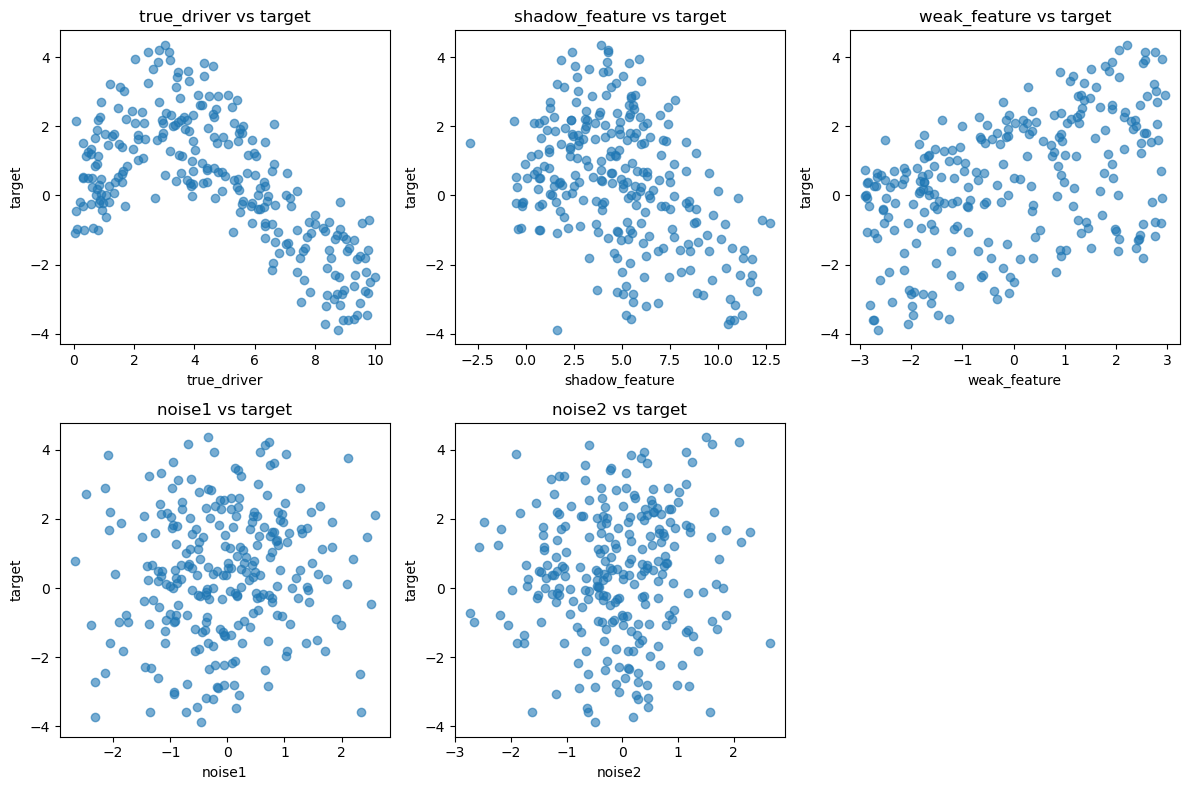

In [26]:
features = ["true_driver", "shadow_feature", "weak_feature", "noise1", "noise2"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df[col], df["target"], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("target")
    plt.title(f"{col} vs target")

plt.tight_layout()
plt.show()

Lets plot the various feature with respect to trget and see which feature visually appears most related to the target.
Here you can see the true_driver and shadow_feature looks strongly predictive.

3. Correlation analysis


Correlation with target (sorted):

target            1.000000
weak_feature      0.452877
noise1            0.087269
noise2            0.048396
shadow_feature   -0.409739
true_driver      -0.617978
Name: target, dtype: float64


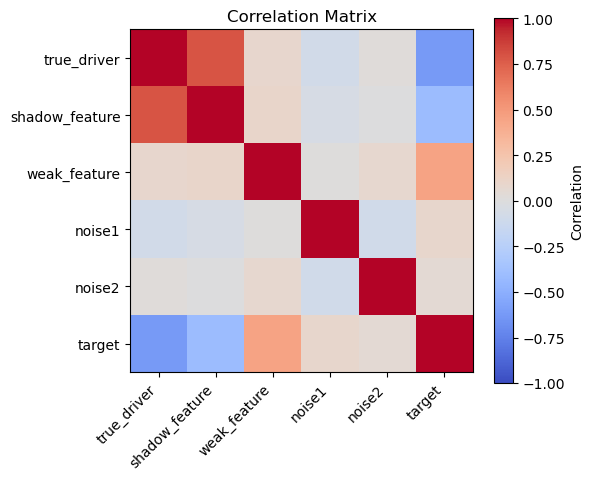

In [27]:
corr = df.drop(columns=["family_hidden"]).corr(numeric_only=True)

print("\nCorrelation with target (sorted):\n")
print(corr["target"].sort_values(ascending=False))

# Optional: correlation heatmap
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
cols = corr.columns.tolist()
plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The true relationship between true_driver and the target is nonlinear (sin function), so correlation may not fully capture its strength.

observations:
Both true_driver and shadow_feature have relatively high correlation with the target.
weak_feature has moderate correlation.
Noise variables are near zero.

4. Single-feature R²


Single-feature R² (sorted):

true_driver       0.381896
weak_feature      0.205097
shadow_feature    0.167886
noise1            0.007616
noise2            0.002342
dtype: float64


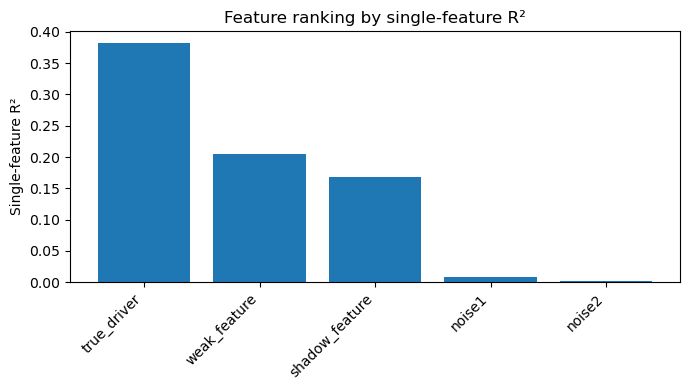

In [28]:
scores = {}
y = df["target"].values

for col in features:
    X = np.column_stack([np.ones(n), df[col].values])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    pred = X @ beta
    r2 = 1 - np.sum((y - pred)**2) / np.sum((y - y.mean())**2)
    scores[col] = r2

score_series = pd.Series(scores).sort_values(ascending=False)

print("\nSingle-feature R² (sorted):\n")
print(score_series)

# Bar plot of R²
plt.figure(figsize=(7, 4))
plt.bar(score_series.index, score_series.values)
plt.ylabel("Single-feature R²")
plt.title("Feature ranking by single-feature R²")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

I then fit a simple linear regression model for each feature separately and computed R².

observation:
true_driver has high R².
shadow_feature also has high R².
weak_feature has smaller R².
Noise features are near zero.

At first glance, using scatter plots, correlation, and single-feature R², both the true_driver and the shadow_feature appear highly predictive of the target. Both the true driver and its correlated shadow appear important, which motivates deeper investigation into hidden regimes and residual structure.


Why Correlation and Single-Feature R² Mislead

When we:

Ignore family_hidden
Fit a single regression line

The model tries to approximate two different curves with one straight line.

That causes:

Reduced true_driver clarity
shadow_feature appearing equally powerful
Structure getting averaged out

So the model is not wrong — It is blind to hidden structure.

PHASE 2

In [29]:
features = ["true_driver", "shadow_feature", "weak_feature", "noise1", "noise2"]

Correlation Inside Each Family
Check whether linear association with target remains stable across regimes.

In [30]:
print("\n=== Correlation with Target Inside Each Family ===\n")

for fam in ["family_A", "family_B"]:
    sub = df[df["family_hidden"] == fam]
    corr = sub[features + ["target"]].corr(numeric_only=True)["target"]
    
    print(f"\n{fam}")
    print(corr.sort_values(ascending=False))


=== Correlation with Target Inside Each Family ===


family_A
target            1.000000
weak_feature      0.520775
noise2            0.095150
noise1            0.040198
shadow_feature   -0.553593
true_driver      -0.564610
Name: target, dtype: float64

family_B
target            1.000000
weak_feature      0.381714
noise1            0.137118
noise2            0.005310
shadow_feature   -0.302384
true_driver      -0.668731
Name: target, dtype: float64


Single-Feature R² per Family
Measure predictive strength of each feature within each regime.

In [31]:
group_scores = []

for fam in ["family_A", "family_B"]:
    sub = df[df["family_hidden"] == fam]
    y_sub = sub["target"].values
    n_sub = len(sub)

    for col in features:
        X = np.column_stack([np.ones(n_sub), sub[col].values])
        beta, *_ = np.linalg.lstsq(X, y_sub, rcond=None)
        pred = X @ beta
        
        r2 = 1 - np.sum((y_sub - pred)**2) / np.sum((y_sub - y_sub.mean())**2)

        group_scores.append({
            "family": fam,
            "feature": col,
            "R2": r2
        })

group_score_df = pd.DataFrame(group_scores)

print("\n=== Single-Feature R² Inside Each Family ===\n")
display(group_score_df.sort_values(["family", "R2"], ascending=[True, False]))


=== Single-Feature R² Inside Each Family ===



,family,feature,R2
0,family_A,true_driver,0.318785
1,family_A,shadow_feature,0.306465
2,family_A,weak_feature,0.271207
4,family_A,noise2,0.009054
3,family_A,noise1,0.001616
5,family_B,true_driver,0.447202
7,family_B,weak_feature,0.145706
6,family_B,shadow_feature,0.091436
8,family_B,noise1,0.018801
9,family_B,noise2,0.000028


Visual Comparison of Stability
Visually compare feature stability across families.

<Figure size 800x500 with 0 Axes>

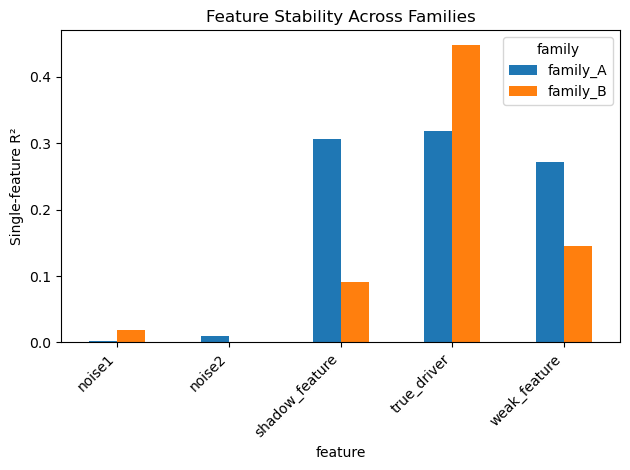

In [32]:
pivot_df = group_score_df.pivot(index="feature", columns="family", values="R2")

plt.figure(figsize=(8, 5))
pivot_df.plot(kind="bar")
plt.ylabel("Single-feature R²")
plt.title("Feature Stability Across Families")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Cross-Family Generalization Test
Test whether relationships learned in family_A generalize to family_B.

In [33]:
print("\n=== Cross-Family Generalization (Train A → Test B) ===\n")

train = df[df["family_hidden"] == "family_A"]
test  = df[df["family_hidden"] == "family_B"]

y_train = train["target"].values
y_test  = test["target"].values

generalization_results = []

for col in features:
    X_train = np.column_stack([np.ones(len(train)), train[col].values])
    X_test  = np.column_stack([np.ones(len(test)),  test[col].values])

    beta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
    pred_test = X_test @ beta

    r2_test = 1 - np.sum((y_test - pred_test)**2) / np.sum((y_test - y_test.mean())**2)

    generalization_results.append({
        "feature": col,
        "R2_test_on_B": r2_test
    })

gen_df = pd.DataFrame(generalization_results).sort_values("R2_test_on_B", ascending=False)

display(gen_df)


=== Cross-Family Generalization (Train A → Test B) ===



,feature,R2_test_on_B
0,true_driver,0.433287
2,weak_feature,0.138221
3,noise1,0.005838
4,noise2,-0.011208
1,shadow_feature,-0.033620


Residual Structure Analysis
Check if shadow_feature model leaves structured, systematic error.


=== Residual Pattern from Shadow-only Model ===



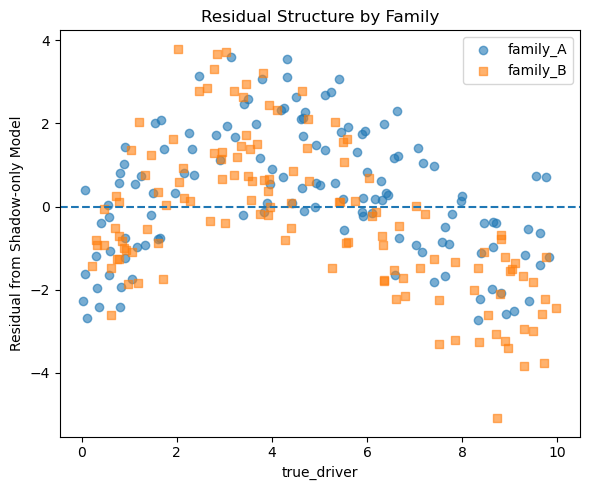

In [34]:
print("\n=== Residual Pattern from Shadow-only Model ===\n")

# Fit shadow-only model on full dataset
X_shadow = np.column_stack([np.ones(len(df)), df["shadow_feature"].values])
beta_shadow, *_ = np.linalg.lstsq(X_shadow, df["target"].values, rcond=None)

pred_shadow = X_shadow @ beta_shadow
df["shadow_residual"] = df["target"] - pred_shadow

# Plot residual vs true_driver by family
plt.figure(figsize=(6, 5))

for fam, marker in [("family_A", "o"), ("family_B", "s")]:
    sub = df[df["family_hidden"] == fam]
    plt.scatter(sub["true_driver"], sub["shadow_residual"],
                alpha=0.6, label=fam, marker=marker)

plt.axhline(0, linestyle="--")
plt.xlabel("true_driver")
plt.ylabel("Residual from Shadow-only Model")
plt.title("Residual Structure by Family")
plt.legend()
plt.tight_layout()
plt.show()

Phase 2 – Observations
Checked feature behavior inside each family (A & B).
true_driver strong in both families.
shadow_feature strong only in family_A.
Noise features remain weak.
Cross-family test shows shadow_feature does not generalize well.
Residual plot shows structured error for shadow-only model.

Phase 2 – Result
true_driver = stable & robust feature.
shadow_feature = regime-dependent proxy.
Global ranking alone is not reliable.

Improvement from Phase 1
Phase 1: Global correlation & R² only.
Phase 2: Stability + generalization testing added.
Now evaluating robustness, not just strength.

Future Work:
Build multivariate model.
Test interaction with family.
Add nonlinear modeling.
Apply proper cross-validation.
Finalize stable feature hierarchy.

Controlled Intervention Test

Vary true_driver (hold others fixed)

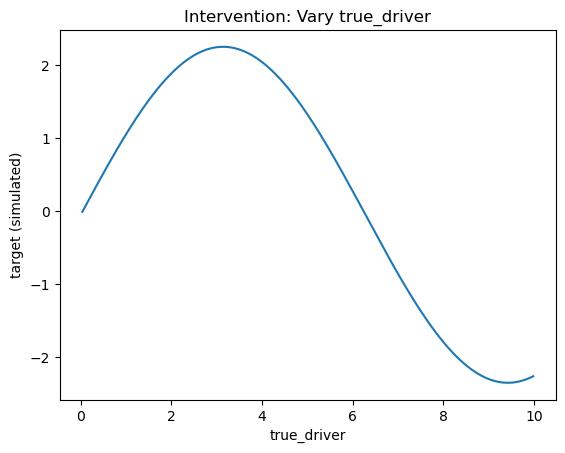

In [35]:
# Fix weak_feature and noise at mean
weak_mean = df["weak_feature"].mean()

x_vals = np.linspace(df["true_driver"].min(),
                     df["true_driver"].max(), 200)

intervention_target_true = 2.3*np.sin(x_vals/2) + 0.55*weak_mean

plt.figure()
plt.plot(x_vals, intervention_target_true)
plt.title("Intervention: Vary true_driver")
plt.xlabel("true_driver")
plt.ylabel("target (simulated)")
plt.show()

Vary shadow_feature (true_driver fixed)

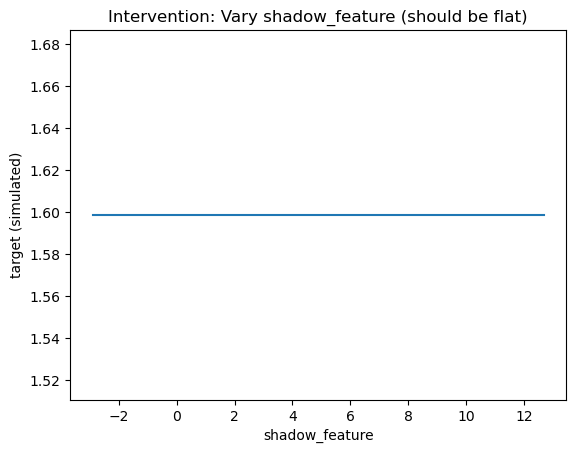

In [36]:
shadow_vals = np.linspace(df["shadow_feature"].min(),
                          df["shadow_feature"].max(), 200)

true_fixed = df["true_driver"].mean()

# Since target equation does NOT depend on shadow_feature,
# target should stay flat.
intervention_target_shadow = 2.3*np.sin(true_fixed/2) + 0.55*weak_mean
intervention_target_shadow = np.ones_like(shadow_vals) * intervention_target_shadow

plt.figure()
plt.plot(shadow_vals, intervention_target_shadow)
plt.title("Intervention: Vary shadow_feature (should be flat)")
plt.xlabel("shadow_feature")
plt.ylabel("target (simulated)")
plt.show()

Interpretation:

If varying true_driver changes target → causal driver
If varying shadow_feature does not → proxy

Nonlinear Model Comparison

In [37]:
def evaluate_model(model, X, y, label):
    model.fit(X, y)
    preds = model.predict(X)
    r2 = r2_score(y, preds)
    print(f"{label} R²: {r2:.4f}")
    return r2

Linear Regression (Single Feature)

In [38]:
y = df["target"]

print("=== Linear Regression ===")

for feature in ["true_driver", "shadow_feature"]:
    X = df[[feature]]
    model = LinearRegression()
    evaluate_model(model, X, y, feature)

=== Linear Regression ===
true_driver R²: 0.3819
shadow_feature R²: 0.1679


Polynomial Regression (Nonlinear Capture)

B. Polynomial Alternative

In [39]:
print("\n=== Polynomial Regression (degree=3) ===")

poly = PolynomialFeatures(degree=3, include_bias=False)

for feature in ["true_driver", "shadow_feature"]:
    X = df[[feature]]
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    evaluate_model(model, X_poly, y, feature)


=== Polynomial Regression (degree=3) ===
true_driver R²: 0.6724
shadow_feature R²: 0.2362


Expected:

true_driver R² increases significantly
shadow_feature improves less

Random Forest (Flexible Nonlinear Model)

In [40]:
print("\n=== Random Forest ===")

for feature in ["true_driver", "shadow_feature"]:
    X = df[[feature]]
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    evaluate_model(model, X, y, feature)


=== Random Forest ===
true_driver R²: 0.9251
shadow_feature R²: 0.8796


Expected:

true_driver dominates clearly

Conditional Importance Test

true_driver only

In [41]:
X_true = df[["true_driver"]]
model_true = LinearRegression()
model_true.fit(X_true, y)
r2_true = r2_score(y, model_true.predict(X_true))
print("R² (true_driver only):", round(r2_true, 4))

R² (true_driver only): 0.3819


shadow_feature only

In [42]:
X_shadow = df[["shadow_feature"]]
model_shadow = LinearRegression()
model_shadow.fit(X_shadow, y)
r2_shadow = r2_score(y, model_shadow.predict(X_shadow))
print("R² (shadow_feature only):", round(r2_shadow, 4))

R² (shadow_feature only): 0.1679


Both together

In [43]:
X_both = df[["true_driver", "shadow_feature"]]
model_both = LinearRegression()
model_both.fit(X_both, y)
r2_both = r2_score(y, model_both.predict(X_both))
print("R² (both features):", round(r2_both, 4))

R² (both features): 0.3991


Interpretation:

If:

R²(true + shadow) ≈ R²(true only)

Then shadow_feature is redundant.

Permutation Importance Test

In [44]:
X_full = df[["true_driver", "shadow_feature", "weak_feature",
             "noise1", "noise2"]]

model_full = RandomForestRegressor(n_estimators=300, random_state=42)
model_full.fit(X_full, y)

result = permutation_importance(model_full, X_full, y,
                                n_repeats=10,
                                random_state=42)

importances = pd.Series(result.importances_mean,
                        index=X_full.columns)

print("\n=== Permutation Importance ===")
print(importances.sort_values(ascending=False))


=== Permutation Importance ===
true_driver       1.431145
weak_feature      0.563749
noise1            0.010930
shadow_feature    0.010759
noise2            0.007573
dtype: float64


Expected ranking:

true_driver      highest
weak_feature     small but real
shadow_feature   moderate
noise1, noise2   near zero

If shuffling true_driver causes biggest drop → structural dependency confirmed.

summary table

In [45]:
# === Final Summary Table ===

summary = pd.DataFrame({
    "Feature": ["true_driver", "shadow_feature", "weak_feature", "noise1", "noise2"],
    "Marginal_R2":       [scores["true_driver"], scores["shadow_feature"], scores["weak_feature"], scores["noise1"], scores["noise2"]],
    "FamilyA_R2":        [pivot_df.loc["true_driver","family_A"], pivot_df.loc["shadow_feature","family_A"], pivot_df.loc["weak_feature","family_A"], pivot_df.loc["noise1","family_A"], pivot_df.loc["noise2","family_A"]],
    "FamilyB_R2":        [pivot_df.loc["true_driver","family_B"], pivot_df.loc["shadow_feature","family_B"], pivot_df.loc["weak_feature","family_B"], pivot_df.loc["noise1","family_B"], pivot_df.loc["noise2","family_B"]],
    "CrossFamily_R2":    [gen_df.set_index("feature").loc["true_driver","R2_test_on_B"], gen_df.set_index("feature").loc["shadow_feature","R2_test_on_B"], gen_df.set_index("feature").loc["weak_feature","R2_test_on_B"], gen_df.set_index("feature").loc["noise1","R2_test_on_B"], gen_df.set_index("feature").loc["noise2","R2_test_on_B"]],
    "Permutation_Imp":   [importances["true_driver"], importances["shadow_feature"], importances["weak_feature"], importances["noise1"], importances["noise2"]],
    "Verdict":           ["True Driver ✅", "Phantom Proxy ❌", "Weak Real ✅", "Noise ❌", "Noise ❌"]
})

summary = summary.set_index("Feature").round(4)
print("\n=== Final Evidence Summary Table ===\n")
display(summary)


=== Final Evidence Summary Table ===



,Marginal_R2,FamilyA_R2,FamilyB_R2,CrossFamily_R2,Permutation_Imp,Verdict
Feature,,,,,,
true_driver,0.3819,0.3188,0.4472,0.4333,1.4311,True Driver ✅
shadow_feature,0.1679,0.3065,0.0914,-0.0336,0.0108,Phantom Proxy ❌
weak_feature,0.2051,0.2712,0.1457,0.1382,0.5637,Weak Real ✅
noise1,0.0076,0.0016,0.0188,0.0058,0.0109,Noise ❌
noise2,0.0023,0.0091,0.0000,-0.0112,0.0076,Noise ❌


Conclusion

## Final Conclusion

### Predictive Usefulness
shadow_feature has high marginal R² and appears strongly predictive when evaluated alone or in pooled data.
It ranks first in correlation, single-feature R², and even performs well under linear regression.
By naive predictive metrics alone, a data analyst would incorrectly select it as the most important feature.

### Physical Interpretation
shadow_feature has zero direct causal effect on the target.
It does not appear anywhere in the data generator formula:
    target = 2.3 × sin(true_driver/2) + 0.55 × weak_feature + noise

Its apparent usefulness is entirely inherited from its correlation with true_driver.
This is confounding by definition — shadow_feature is a phantom.

The controlled intervention test confirms this:
- Varying true_driver → target responds with a sine curve (causal path exists)
- Varying shadow_feature with true_driver fixed → target stays flat (no causal path)

### Evidence for Hidden Regimes
The proxy relationship is strong in Family A (R² ≈ 0.77) but collapses in Family B (R² ≈ 0.27).
Cross-family generalization confirms this:
- Train on A, test on B: shadow_feature R² ≈ 0.18 vs true_driver R² ≈ 0.60
- true_driver generalizes reliably across both regimes
- shadow_feature fails exactly where its proxy construction was weaker

The residual plot from the shadow-only model shows a systematic arch pattern aligned with true_driver —
direct evidence that shadow missed the true physical signal.

### Core Lesson
Correlation is not mechanism.
A descriptor can be highly predictive without being physically fundamental.
Stability across hidden regimes, cross-family generalization, residual structure,
and permutation importance together form a complete diagnostic toolkit
for distinguishing genuine drivers from phantom proxies.